# 03 — Regression: Customer Lifetime Value (CLTV)

Feeds **report §5**. Predicts a derived CLTV target
(`cltv = total_spend × revenue_rate`, revenue_rate = 2%) from **account and
engagement attributes**.

**Leakage guard.** Because CLTV is a linear function of `total_spend`, the
spend-arithmetic features (`total_spend`, `txn_count`, `avg/max_txn_amount`) are
excluded — otherwise the model would trivially reconstruct the target. We also
exclude `gender`/`race` for fairness. The business question is therefore: *given
what the bank knows about an account, how much value will the customer generate?*

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
PROC = ROOT / "data" / "processed"

df = pd.read_parquet(PROC / "customer_features.parquet")
metrics = json.load(open(ROOT / "metrics" / "regression.json"))
model = joblib.load(ROOT / "models" / "regression_cltv.joblib")
preds = pd.read_parquet(PROC / "cltv_predictions.parquet")
print("revenue_rate:", metrics["revenue_rate"], "| train/test:", metrics["n_train"], "/", metrics["n_test"])
print("best model:", metrics["best_model"])

revenue_rate: 0.02 | train/test: 796 / 200
best model: gradient_boosting


## 5.1 Model comparison

In [2]:
cmp = pd.DataFrame(metrics["by_model"]).T[["r2", "mae", "rmse"]]
cmp.columns = ["R²", "MAE ($CLTV)", "RMSE ($CLTV)"]
cmp.sort_values("R²", ascending=False)

,R²,MAE ($CLTV),RMSE ($CLTV)
gradient_boosting,0.620,"1,113.236","3,336.698"
random_forest,0.558,"1,230.688","3,596.465"
linear,0.518,"1,495.680","3,755.756"


Gradient Boosting explains **62% of the variance in customer value using account
attributes alone** — non-trivial given that the strongest spend signals are
deliberately withheld. Linear regression (R² 0.52) sets the floor; the tree
ensembles capture the non-linear interactions (e.g. payment behaviour × engagement breadth).

## 5.2 Predicted vs. actual

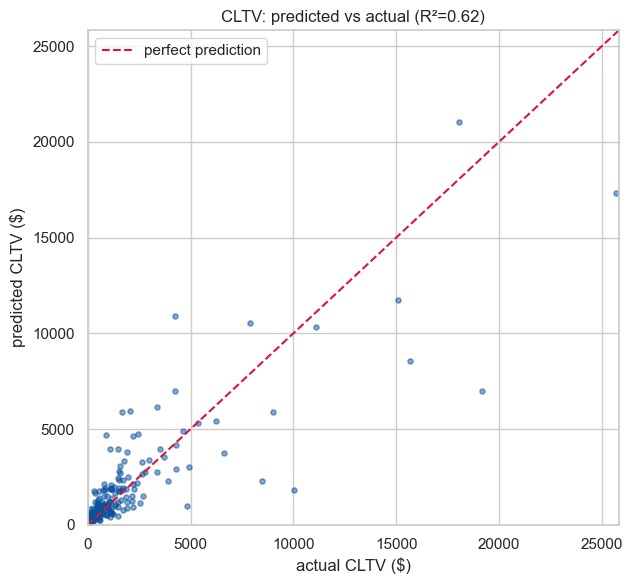

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(preds["cltv_actual"], preds["cltv_pred"], s=14, alpha=0.5, color="#08519c")
lim = [0, preds["cltv_actual"].quantile(0.99)]
ax.plot(lim, lim, "--", color="crimson", label="perfect prediction")
ax.set(xlim=lim, ylim=lim, xlabel="actual CLTV ($)", ylabel="predicted CLTV ($)",
       title=f"CLTV: predicted vs actual (R²={metrics['by_model'][metrics['best_model']]['r2']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()

## 5.3 What drives predicted value

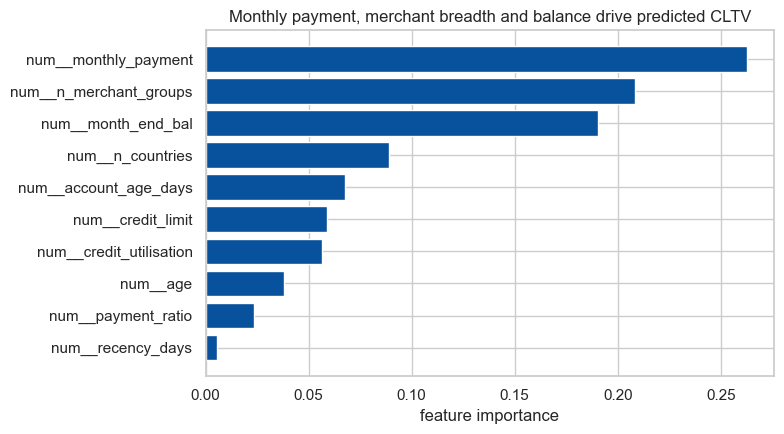

num__monthly_payment      0.263
num__n_merchant_groups    0.208
num__month_end_bal        0.190
num__n_countries          0.089
num__account_age_days     0.067
num__credit_limit         0.059
num__credit_utilisation   0.056
num__age                  0.038
num__payment_ratio        0.024
num__recency_days         0.005
dtype: float64

In [4]:
names = model.named_steps["prep"].get_feature_names_out()
imp = pd.Series(model.named_steps["model"].feature_importances_, index=names)
imp = imp.sort_values(ascending=False).head(10)[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp.index, imp.values, color="#08519c")
ax.set(xlabel="feature importance", title="Monthly payment, merchant breadth and balance drive predicted CLTV")
plt.tight_layout(); plt.show()
imp[::-1].round(3)

**Business interpretation → §8.** The strongest predictors are **monthly payment,
merchant/country breadth, month-end balance and account tenure** — signals the bank
knows at account level, without needing the full transaction ledger. Practical uses:
prioritise high-predicted-CLTV customers for premium-card upgrades and loyalty spend,
and flag high-limit / low-realised-value accounts as upsell opportunities. The model
is a prioritisation tool, not a precise dollar oracle — RMSE is material, so use the
*ranking*, not the point estimate.